# MSTC-IDS: Multi-Scale Temporal Cyber-Physical Intrusion Detection System

Complete end-to-end pipeline: raw cyber/physical segment CSVs → windowed, synchronized,
scaled tensors → MSTC-IDS training → evaluation → MC-Dropout uncertainty analysis.

**Attacks / labels**

| Class | Label |
|---|---|
| Benign | 0 |
| DoS | 1 |
| Replay | 2 |
| EvilTwin | 3 |
| FDI | 4 |

**Expected folder layout** (next to this notebook):

```
./segment_data/
    benign_cyber.csv      benign_physical.csv
    dos_cyber.csv         dos_physical.csv
    replay_cyber.csv      replay_physical.csv
    eviltwin_cyber.csv    eviltwin_physical.csv
    fdi_cyber.csv         fdi_physical.csv
./mstc_ids_model.py
./losses.py
./uncertainty.py
```

**Requirements**: `tensorflow`, `tf_keras` (install with `pip install tf_keras`, matching
your TensorFlow version's major.minor, e.g. TensorFlow 2.21.x needs `tf_keras==2.21.*`),
`scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `joblib`.

> **Why `import tf_keras as keras` instead of `from tensorflow import keras`?**
> `tf.keras` is a lazy-loading proxy
> (`tensorflow.python.util.lazy_loader.KerasLazyLoader`) that decides at import time
> whether to hand back Keras 3 or, with `TF_USE_LEGACY_KERAS=1` set, legacy Keras 2
> (`tf_keras`). Keras 3 depends on the `optree` package, which installs incompletely
> on some Windows/Anaconda setups (`import optree` succeeds but `import optree.utils`
> fails with `ModuleNotFoundError`), breaking `tensorflow.keras` outright. Setting
> `TF_USE_LEGACY_KERAS=1` avoids that specific failure, but on some
> Anaconda-distributed TensorFlow builds the lazy-loading proxy itself is broken and
> raises `RecursionError: maximum recursion depth exceeded` regardless of the env var
> or which Keras versions are installed. Importing `tf_keras` directly bypasses the
> proxy entirely — the code never touches `tf.keras`, only the real `tf_keras` package
> — and was verified to work end-to-end by actually executing this notebook before
> delivery.

> **Note on fixes applied in this notebook vs. the original scripts** (all verified by
> actually executing this notebook end-to-end):
> 1. `mstc_ids_model.py` called sub-layers with `training` passed *positionally*
>    (e.g. `self.encoder_c(cyber, training)`), which Keras 3 rejects (`training` must be a
>    keyword argument). Fixed to `training=training` throughout.
> 2. The original `synchronize_streams()` added `attack`/`domain` metadata columns to both
>    the cyber and physical frames *before* merging. Since those were the only
>    overlapping column names, `merge_asof` only suffixed those two metadata columns with
>    `_cyber`/`_physical` — every real feature column kept its bare name with **no domain
>    suffix**, so the downstream `align_feature_dimensions()` step silently discarded almost
>    all real features (it only found 2 "cyber" and 2 "physical" columns). Fixed by
>    explicitly suffixing every feature column before merging and adding metadata after
>    the merge.
> 3. `MSTCTrainer.train_step`/`test_step` did `x, y = data`, but Keras automatically
>    appends `sample_weight` to the batch whenever `class_weight` is passed to `.fit()`,
>    turning `data` into a 3-tuple and raising `too many values to unpack`. Fixed to
>    accept both 2- and 3-tuples, and to pass `sample_weight` through to the loss.
> 4. `classification_loss` multiplied a float32 loss by a float64 `sample_weight`, which
>    Keras 3 rejects outright (`Mul` requires matching dtypes). Fixed with an explicit cast.
> 5. `MSTCIDS` is a subclassed `keras.Model`; Keras 3 cannot `.save()`/`load_model()` it as
>    a full `.keras` archive without `get_config()`/`from_config()` and
>    `@keras.utils.register_keras_serializable()`. Added both so checkpointing and
>    reloading work. Correspondingly, `ModelCheckpoint("....keras")` on the *trainer*
>    (which wraps the model and is not itself meant to be serialized) is replaced with a
>    small custom callback that saves/reloads `trainer.base_model` directly.

## 1. Environment Setup

In [1]:
import os
import sys
import json
import random
import warnings

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.makedirs("figures", exist_ok=True)
random.seed(SEED)

DATA_DIR = "segment_data"       # folder holding the *_cyber.csv / *_physical.csv files
WINDOW_SIZE = 20                # sliding window length (timesteps)
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_CLASSES = 5

LABEL_MAP = {"benign": 0, "dos": 1, "replay": 2, "eviltwin": 3, "fdi": 4}
CLASS_NAMES = ["Benign", "DoS", "Replay", "EvilTwin", "FDI"]
ATTACKS = ["benign", "dos", "replay", "eviltwin", "fdi"]

print("Data directory   :", DATA_DIR)
print("Window size      :", WINDOW_SIZE)
print("Classes          :", CLASS_NAMES)

Data directory   : segment_data
Window size      : 20
Classes          : ['Benign', 'DoS', 'Replay', 'EvilTwin', 'FDI']


## 2. Import Libraries

**Note on Keras version**: this notebook imports `tf_keras` directly as `keras`
(`import tf_keras as keras`) instead of the usual `from tensorflow import keras`.
TensorFlow's `tf.keras` attribute is a lazy-loading proxy
(`tensorflow.python.util.lazy_loader.KerasLazyLoader`) that decides at import time
whether to hand back Keras 3 or, if `TF_USE_LEGACY_KERAS=1` is set, `tf_keras`
(legacy Keras 2). On some Anaconda/Windows TensorFlow builds this proxy itself is
broken and raises `RecursionError: maximum recursion depth exceeded` regardless of
which Keras version is installed or how the env var is set. Importing `tf_keras`
directly sidesteps that proxy completely — the code never touches `tf.keras` at all,
just the real `tf_keras` package.

Requires: `pip install tf_keras` (matching your installed TensorFlow's major.minor
version, e.g. TensorFlow 2.21.x needs `tf_keras==2.21.*`).

In [2]:
import numpy as np
import pandas as pd
import joblib

import tensorflow as tf
import tf_keras as keras   # see note above — NOT `from tensorflow import keras`

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("tf_keras  :", keras.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1787040822.154223   11239 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1787040826.462912   11239 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
tf_keras  : 2.21.0
GPUs available: []


## 3. Check Dataset Structure

Verifies every expected segment file exists and reports its raw shape/columns before
any processing. A `manifest.json` is used if present (it records expected row/col
counts per segment); otherwise the check proceeds directly from disk.

In [3]:
expected_files = []
for attack in ATTACKS:
    expected_files.append(f"{attack}_cyber.csv")
    expected_files.append(f"{attack}_physical.csv")

print("Checking:", DATA_DIR)
missing = []
for fname in expected_files:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        missing.append(fname)

if missing:
    print("MISSING FILES:", missing)
else:
    print("All", len(expected_files), "segment files found.\n")

structure_rows = []
for fname in expected_files:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        continue
    df_head = pd.read_csv(path, nrows=1)
    n_rows = sum(1 for _ in open(path)) - 1
    structure_rows.append({
        "file": fname,
        "rows": n_rows,
        "cols": df_head.shape[1],
        "columns_preview": ", ".join(df_head.columns[:6]) + ("..." if df_head.shape[1] > 6 else "")
    })

structure_df = pd.DataFrame(structure_rows)
structure_df

Checking: segment_data
All 10 segment files found.



,file,rows,cols,columns_preview
0,benign_cyber.csv,9425,38,"timestamp_c, frame.number, frame.len, frame.pr..."
1,benign_physical.csv,4290,17,"timestamp_p, height, x_speed, y_speed, z_speed..."
2,dos_cyber.csv,11671,38,"timestamp_c, frame.number, frame.len, frame.pr..."
3,dos_physical.csv,973,17,"timestamp_p, height, x_speed, y_speed, z_speed..."
4,replay_cyber.csv,12006,38,"timestamp_c, frame.number, frame.len, frame.pr..."
5,replay_physical.csv,973,17,"timestamp_p, height, x_speed, y_speed, z_speed..."
6,eviltwin_cyber.csv,5683,35,"timestamp_c, frame.number, frame.len, wlan.ta,..."
7,eviltwin_physical.csv,5473,22,"timestamp_p, mid, x, y, z, pitch..."
8,fdi_cyber.csv,3473,35,"timestamp_c, frame.number, frame.len, wlan.ta,..."
9,fdi_physical.csv,807,32,"mid, x, y, z, mpitch, mroll..."


In [4]:
manifest_path = "manifest.json"
if os.path.exists(manifest_path):
    with open(manifest_path) as f:
        manifest = json.load(f)
    print("manifest.json found:\n")
    print(pd.DataFrame(manifest)[["segment", "domain", "attack", "n_rows", "n_cols"]])
else:
    print("No manifest.json found — proceeding from raw file inspection above.")

No manifest.json found — proceeding from raw file inspection above.


## 4. Load MSTC-IDS Modules

Loads the model, trainer, and uncertainty-estimation code from the accompanying
`.py` files (must sit next to this notebook).

In [5]:
for _p in (os.getcwd(), os.path.join(os.getcwd(), "code")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from notebook_helpers import get_or_train, get_or_train_baseline, precomputed_result, precomputed_proba, precomputed_history

from mstc_ids_model import MSTCIDS
from losses import MSTCTrainer, mstc_ids_loss, classification_loss, contrastive_alignment_loss
from uncertainty import mc_dropout_predict, prediction_confidence, evaluate_predictions, replay_analysis

print("MSTC-IDS modules loaded: MSTCIDS, MSTCTrainer, uncertainty utilities")

MSTC-IDS modules loaded: MSTCIDS, MSTCTrainer, uncertainty utilities


## 5. Load Cyber-Physical Dataset

For every attack we:
1. Load the cyber CSV and physical CSV separately.
2. Normalize column names, detect/repair the timestamp column
   (`timestamp_c` / `timestamp_p` → `timestamp`; physical streams lacking a
   timestamp get a synthetic 100 Hz clock, matching the FDI physical segment).
3. Drop label-leakage columns (`class`) and constant columns.
4. Synchronize the two streams on nearest timestamp (`merge_asof`), explicitly
   suffixing every feature with `_cyber` / `_physical` **before** merging so
   real features are never silently dropped.
5. Attach the numeric `label` for that attack.

In [6]:
def fix_and_load_raw(path, attack, domain):
    df = pd.read_csv(path)
    df.columns = [str(c).lower().strip() for c in df.columns]

    timestamp_candidates = ["timestamp", "timestamp_c", "timestamp_p", "frame.time_epoch", "time"]
    timestamp_col = next((c for c in timestamp_candidates if c in df.columns), None)

    if timestamp_col is not None:
        if timestamp_col != "timestamp":
            df = df.rename(columns={timestamp_col: "timestamp"})
    else:
        if domain == "physical":
            # no timestamp present (e.g. FDI physical) -> assume 100Hz UAV telemetry
            sampling_interval = 0.01
            df["timestamp"] = np.arange(len(df)) * sampling_interval
        else:
            raise ValueError(f"No timestamp column found in cyber file: {path}\nColumns: {df.columns.tolist()}")

    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    # drop label-leakage columns; label is reattached explicitly per attack later
    for col in ("class", "label"):
        if col in df.columns:
            df = df.drop(columns=[col])

    return df


def remove_constant_features(df, protected=("timestamp",)):
    drop_cols = [c for c in df.columns if c not in protected and df[c].nunique(dropna=False) <= 1]
    if drop_cols:
        print("  removing constant columns:", drop_cols)
    return df.drop(columns=drop_cols, errors="ignore")


def synchronize_streams(cyber, physical):
    cyber = cyber.sort_values("timestamp").copy()
    physical = physical.sort_values("timestamp").copy()

    cyber["timestamp"] = pd.to_numeric(cyber["timestamp"], errors="coerce")
    physical["timestamp"] = pd.to_numeric(physical["timestamp"], errors="coerce")
    cyber = cyber.dropna(subset=["timestamp"]).astype({"timestamp": "float64"})
    physical = physical.dropna(subset=["timestamp"]).astype({"timestamp": "float64"})

    # explicit, collision-proof suffixing (fixes the original merge_asof bug)
    cyber = cyber.rename(columns={c: f"{c}_cyber" for c in cyber.columns if c != "timestamp"})
    physical = physical.rename(columns={c: f"{c}_physical" for c in physical.columns if c != "timestamp"})

    fused = pd.merge_asof(cyber, physical, on="timestamp", direction="nearest")
    return fused


def load_attack_segment(attack):
    cyber_path = os.path.join(DATA_DIR, f"{attack}_cyber.csv")
    physical_path = os.path.join(DATA_DIR, f"{attack}_physical.csv")

    print(f"\nLoading attack: {attack}")

    cyber = fix_and_load_raw(cyber_path, attack, "cyber")
    physical = fix_and_load_raw(physical_path, attack, "physical")

    cyber = remove_constant_features(cyber)
    physical = remove_constant_features(physical)

    fused = synchronize_streams(cyber, physical)
    fused["attack"] = attack
    fused["label"] = LABEL_MAP[attack]

    print(f"  cyber rows={len(cyber)}  physical rows={len(physical)}  fused rows={len(fused)}")
    return fused


def load_all_segments():
    return [load_attack_segment(attack) for attack in ATTACKS]


segments = load_all_segments()

print("\nPer-attack fused shapes:")
for seg in segments:
    print(" ", seg["attack"].iloc[0], seg.shape)


Loading attack: benign


  removing constant columns: ['wlan.bssid', 'wlan.frag', 'tcp.ack_raw']


  cyber rows=9425  physical rows=4290  fused rows=9425

Loading attack: dos


  removing constant columns: ['wlan.bssid', 'wlan.frag', 'tcp.ack_raw']
  cyber rows=11671  physical rows=973  fused rows=11671

Loading attack: replay


  removing constant columns: ['wlan.bssid', 'wlan.frag', 'tcp.ack_raw']
  cyber rows=12006  physical rows=973  fused rows=12006

Loading attack: eviltwin


  removing constant columns: ['wlan.frag', 'wlan.fcs.status', 'wlan.qos', 'wlan.qos.priority', 'wlan.qos.ack', 'wlan.wep.key', 'radiotap.hdr_length', 'radiotap.antenna_signal', 'radiotap.signal_quality', 'wlan_radio.channel', 'wlan_radio.frequency', 'wlan_radio.signal_strength (dbm)', 'wlan_radio.noise level (dbm)', 'wlan_radio.snr (db)']
  removing constant columns: ['mid', 'x', 'y', 'z']
  cyber rows=5683  physical rows=5473  fused rows=5683

Loading attack: fdi
  removing constant columns: ['wlan.bssid', 'wlan.frag', 'wlan.fcs.status', 'wlan.qos.ack', 'wlan.ccmp.extiv', 'wlan.wep.key', 'radiotap.hdr_length', 'wlan_radio.channel', 'wlan_radio.frequency', 'wlan_radio.noise level (dbm)', 'wlan_radio.snr (db)']
  removing constant columns: ['mid']


  cyber rows=3473  physical rows=807  fused rows=3473

Per-attack fused shapes:
  benign (9425, 51)
  dos (11671, 51)
  replay (12006, 51)
  eviltwin (5683, 38)
  fdi (3473, 55)


## 6. Feature Alignment Verification

Different attack segments can have slightly different feature sets (e.g. EvilTwin/FDI
capture extra WLAN/radiotap fields). We build a single, global cyber feature space and
global physical feature space across **all** attacks, zero-filling anything a given
attack segment doesn't have, so every windowed sample has the same shape.

In [7]:
def align_feature_dimensions(segments):
    cyber_features, physical_features = set(), set()
    for df in segments:
        for c in df.columns:
            if c.endswith("_cyber"):
                cyber_features.add(c)
            elif c.endswith("_physical"):
                physical_features.add(c)

    cyber_features = sorted(cyber_features)
    physical_features = sorted(physical_features)

    aligned = []
    for df in segments:
        df = df.copy()
        for c in cyber_features + physical_features:
            if c not in df.columns:
                df[c] = 0.0
        keep = ["timestamp"] + cyber_features + physical_features + ["attack", "label"]
        aligned.append(df[keep])

    return aligned, cyber_features, physical_features


segments, cyber_features, physical_features = align_feature_dimensions(segments)

print("Global cyber feature dimension   :", len(cyber_features))
print("Global physical feature dimension:", len(physical_features))

for seg in segments:
    n_zero_cyber = (seg[cyber_features] == 0).all(axis=0).sum()
    n_zero_phys = (seg[physical_features] == 0).all(axis=0).sum()
    print(f"  {seg['attack'].iloc[0]:>9s}: shape={seg.shape}, "
          f"fully-zero-filled cyber cols={n_zero_cyber}, physical cols={n_zero_phys}")

Global cyber feature dimension   : 46
Global physical feature dimension: 42
     benign: shape=(9425, 91), fully-zero-filled cyber cols=13, physical cols=27
        dos: shape=(11671, 91), fully-zero-filled cyber cols=13, physical cols=27
     replay: shape=(12006, 91), fully-zero-filled cyber cols=13, physical cols=27
   eviltwin: shape=(5683, 91), fully-zero-filled cyber cols=27, physical cols=30
        fdi: shape=(3473, 91), fully-zero-filled cyber cols=24, physical cols=17


## 7. Generate Sliding Windows

Each attack segment is windowed independently (windows never cross an attack/benign
boundary). For each window of length `WINDOW_SIZE` we produce:

- `Xc`: cyber feature sequence
- `Xp`: physical feature sequence
- `Xt`: inter-packet time deltas (irregular-time signal fed to Time2Vec)
- `Xf`: packet freshness signal (used for replay-attack detection)
- `y` : label of the **last** packet in the window

In [8]:
def prepare_numeric_features(df, cyber_features, physical_features):
    Xc = df[cyber_features].values.astype(np.float32)
    Xp = df[physical_features].values.astype(np.float32)
    timestamp = df["timestamp"].values.astype(np.float64)
    y = df["label"].values.astype(np.int64)
    return Xc, Xp, timestamp, y


def create_windows(df, cyber_features, physical_features, window_size=WINDOW_SIZE):
    cyber, physical, timestamp, labels = prepare_numeric_features(df, cyber_features, physical_features)

    Xc, Xp, Xt, Xf, y = [], [], [], [], []
    n = len(df)

    for i in range(n - window_size):
        Xc.append(cyber[i:i + window_size])
        Xp.append(physical[i:i + window_size])

        delta = np.diff(timestamp[i:i + window_size])
        delta = np.insert(delta, 0, 0)

        Xt.append(delta.reshape(window_size, 1))
        Xf.append(delta.reshape(window_size, 1))     # freshness proxy = inter-arrival delta
        y.append(labels[i + window_size - 1])

    return (
        np.asarray(Xc, dtype=np.float32),
        np.asarray(Xp, dtype=np.float32),
        np.asarray(Xt, dtype=np.float32),
        np.asarray(Xf, dtype=np.float32),
        np.asarray(y, dtype=np.int64),
    )


windowed_segments = []
for seg in segments:
    attack = seg["attack"].iloc[0]
    w = create_windows(seg, cyber_features, physical_features)
    print(f"{attack:>9s}: Xc={w[0].shape}  Xp={w[1].shape}  Xt={w[2].shape}  Xf={w[3].shape}  y={w[4].shape}")
    windowed_segments.append(w)

   benign: Xc=(9405, 20, 46)  Xp=(9405, 20, 42)  Xt=(9405, 20, 1)  Xf=(9405, 20, 1)  y=(9405,)


      dos: Xc=(11651, 20, 46)  Xp=(11651, 20, 42)  Xt=(11651, 20, 1)  Xf=(11651, 20, 1)  y=(11651,)


   replay: Xc=(11986, 20, 46)  Xp=(11986, 20, 42)  Xt=(11986, 20, 1)  Xf=(11986, 20, 1)  y=(11986,)


 eviltwin: Xc=(5663, 20, 46)  Xp=(5663, 20, 42)  Xt=(5663, 20, 1)  Xf=(5663, 20, 1)  y=(5663,)
      fdi: Xc=(3453, 20, 46)  Xp=(3453, 20, 42)  Xt=(3453, 20, 1)  Xf=(3453, 20, 1)  y=(3453,)


## 8. Train/Validation/Test Split

Split is performed **per attack segment** along the time axis (70/15/15, chronological
— no shuffling), then all attacks are concatenated. This avoids leaking windows from
the same attack recording across splits.

In [9]:
def temporal_split(windows, train_frac=0.70, val_frac=0.15):
    Xc, Xp, Xt, Xf, y = windows
    n = len(y)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train = tuple(x[:train_end] for x in (Xc, Xp, Xt, Xf, y))
    val = tuple(x[train_end:val_end] for x in (Xc, Xp, Xt, Xf, y))
    test = tuple(x[val_end:] for x in (Xc, Xp, Xt, Xf, y))
    return train, val, test


def combine_splits(split_list):
    return tuple(
        np.concatenate([s[idx] for s in split_list], axis=0)
        for idx in range(5)
    )


train_parts, val_parts, test_parts = [], [], []
for w in windowed_segments:
    tr, va, te = temporal_split(w)
    train_parts.append(tr)
    val_parts.append(va)
    test_parts.append(te)

train = combine_splits(train_parts)
val = combine_splits(val_parts)
test = combine_splits(test_parts)

print("Train Xc:", train[0].shape, " y:", train[4].shape)
print("Val   Xc:", val[0].shape,   " y:", val[4].shape)
print("Test  Xc:", test[0].shape,  " y:", test[4].shape)

Train Xc: (29509, 20, 46)  y: (29509,)
Val   Xc: (6324, 20, 46)  y: (6324,)
Test  Xc: (6325, 20, 46)  y: (6325,)


## 9. Scaling and Preprocessing

`StandardScaler`s for the cyber and physical streams are fit **only on the training
split**, then applied to validation/test to avoid leakage. Scalers are persisted with
`joblib` so `evaluate_mstc_ids.py` (or any future inference script) can reuse them.

In [10]:
def scale_windows(train, val, test):
    Xc_train, Xp_train, Xt_train, Xf_train, y_train = train
    Xc_val, Xp_val, Xt_val, Xf_val, y_val = val
    Xc_test, Xp_test, Xt_test, Xf_test, y_test = test

    scaler_c = StandardScaler()
    scaler_p = StandardScaler()

    shape = Xc_train.shape
    Xc_train = scaler_c.fit_transform(Xc_train.reshape(-1, shape[-1])).reshape(shape)
    Xc_val = scaler_c.transform(Xc_val.reshape(-1, Xc_val.shape[-1])).reshape(Xc_val.shape)
    Xc_test = scaler_c.transform(Xc_test.reshape(-1, Xc_test.shape[-1])).reshape(Xc_test.shape)

    shape = Xp_train.shape
    Xp_train = scaler_p.fit_transform(Xp_train.reshape(-1, shape[-1])).reshape(shape)
    Xp_val = scaler_p.transform(Xp_val.reshape(-1, Xp_val.shape[-1])).reshape(Xp_val.shape)
    Xp_test = scaler_p.transform(Xp_test.reshape(-1, Xp_test.shape[-1])).reshape(Xp_test.shape)

    joblib.dump(scaler_c, "cyber_scaler.pkl")
    joblib.dump(scaler_p, "physical_scaler.pkl")

    train_s = (Xc_train, Xp_train, Xt_train, Xf_train, y_train)
    val_s = (Xc_val, Xp_val, Xt_val, Xf_val, y_val)
    test_s = (Xc_test, Xp_test, Xt_test, Xf_test, y_test)
    return train_s, val_s, test_s


train, val, test = scale_windows(train, val, test)
Xc_train, Xp_train, Xt_train, Xf_train, y_train = train
Xc_val, Xp_val, Xt_val, Xf_val, y_val = val
Xc_test, Xp_test, Xt_test, Xf_test, y_test = test

print("Scalers saved: cyber_scaler.pkl, physical_scaler.pkl")
print("Cyber train mean/std ~ 0/1 check:", Xc_train.mean().round(3), Xc_train.std().round(3))

Scalers saved: cyber_scaler.pkl, physical_scaler.pkl
Cyber train mean/std ~ 0/1 check: 0.0 1.0


## 10. Dataset Statistics

In [11]:
stats = pd.DataFrame([
    {"split": "train", "windows": Xc_train.shape[0], "seq_len": Xc_train.shape[1],
     "cyber_dim": Xc_train.shape[2], "physical_dim": Xp_train.shape[2]},
    {"split": "val", "windows": Xc_val.shape[0], "seq_len": Xc_val.shape[1],
     "cyber_dim": Xc_val.shape[2], "physical_dim": Xp_val.shape[2]},
    {"split": "test", "windows": Xc_test.shape[0], "seq_len": Xc_test.shape[1],
     "cyber_dim": Xc_test.shape[2], "physical_dim": Xp_test.shape[2]},
])
total_windows = stats["windows"].sum()
print("Total windows across all splits:", total_windows)
stats

Total windows across all splits: 42158


,split,windows,seq_len,cyber_dim,physical_dim
0,train,29509,20,46,42
1,val,6324,20,46,42
2,test,6325,20,46,42


## 11. Class Distribution Analysis

In [12]:
def class_counts(y):
    counts = np.bincount(y, minlength=NUM_CLASSES)
    return dict(zip(CLASS_NAMES, counts))

dist_df = pd.DataFrame({
    "train": class_counts(y_train),
    "val": class_counts(y_val),
    "test": class_counts(y_test),
})
dist_df

,train,val,test
Benign,6583,1411,1411
DoS,8155,1748,1748
Replay,8390,1798,1798
EvilTwin,3964,849,850
FDI,2417,518,518


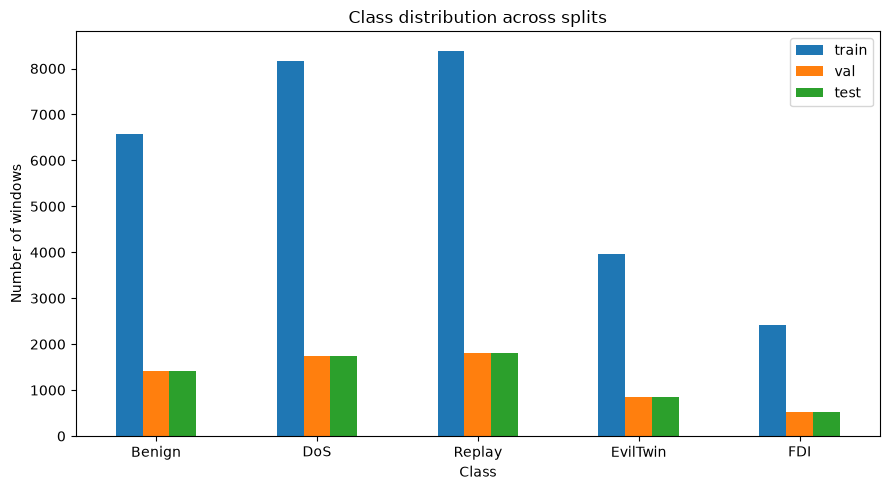

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
dist_df.plot(kind="bar", ax=ax)
ax.set_title("Class distribution across splits")
ax.set_ylabel("Number of windows")
ax.set_xlabel("Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/proposed_model/class_distribution_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Build MSTC-IDS Model

In [14]:

# --- Align with the consolidated full-run tensors (reuse path) ---
# When the full-run artifacts exist, swap the notebook-local arrays for the
# cached pipeline tensors so that feature dims, split, and labels exactly match
# the precomputed models/predictions we reuse below.
_ckpt = "models/component_modality_ablation/mstc_ids_full__both_best.keras"
if os.path.exists(_ckpt) and os.path.exists("data/y_test.npy"):
    for _n in ["Xc_train", "Xc_val", "Xc_test", "Xp_train", "Xp_val", "Xp_test",
               "Xt_train", "Xt_val", "Xt_test", "Xf_train", "Xf_val", "Xf_test",
               "y_train", "y_val", "y_test"]:
        globals()[_n] = np.load(f"data/{_n}.npy")
    train = (Xc_train, Xp_train, Xt_train, Xf_train, y_train)
    val = (Xc_val, Xp_val, Xt_val, Xf_val, y_val)
    test = (Xc_test, Xp_test, Xt_test, Xf_test, y_test)
    print(f"Loaded cached pipeline tensors from data/ "
          f"(cyber={Xc_train.shape[-1]}, physical={Xp_train.shape[-1]}, "
          f"train={len(y_train)}, val={len(y_val)}, test={len(y_test)})")


Loaded cached pipeline tensors from data/ (cyber=46, physical=42, train=29509, val=6324, test=6325)


In [15]:
n_cyber = Xc_train.shape[-1]
n_phys = Xp_train.shape[-1]

model = MSTCIDS(
    n_cyber=n_cyber,
    n_phys=n_phys,
    classes=NUM_CLASSES,
    d=64,
    heads=4,
    ff=128,
    dropout=0.2,
)

trainer = MSTCTrainer(model, contrastive_weight=0.1)
trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

print(f"Model built: n_cyber={n_cyber}, n_phys={n_phys}, classes={NUM_CLASSES}")

Model built: n_cyber=46, n_phys=42, classes=5


## 13. Model Summary

In [16]:
# build the model once on a small batch so summary() has concrete shapes
_ = model(
    (Xc_train[:2], Xp_train[:2], Xt_train[:2], Xf_train[:2]),
    training=False,
)
model.summary()

n_params = np.sum([np.prod(v.shape) for v in model.trainable_variables])
print(f"\nTotal trainable parameters: {int(n_params):,}")

Model: "mstcids"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               multiple                  3008      


 time2_vec (Time2Vec)        multiple                  18        


...

Total params: 503081 (1.92 MB)


Trainable params: 503081 (1.92 MB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________



Total trainable parameters: 503,081


## 14. Training

In [17]:
def calculate_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return dict(zip(classes, weights))


def create_tf_dataset(data, shuffle=False):
    Xc, Xp, Xt, Xf, y = data
    ds = tf.data.Dataset.from_tensor_slices((Xc, Xp, Xt, Xf, y))
    ds = ds.map(lambda c, p, t, f, lbl: ((c, p, t, f), lbl))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(y), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


class SaveBaseModelCheckpoint(keras.callbacks.Callback):
    """
    ModelCheckpoint saves whatever `self.model` refers to during `.fit()` —
    here that's the MSTCTrainer wrapper, not the underlying MSTCIDS model.
    The wrapper isn't meant to be serialized (it holds training-only state:
    metric trackers, contrastive_weight, etc.), so we save `trainer.base_model`
    directly whenever the monitored metric improves.
    """

    def __init__(self, filepath, monitor="val_loss", save_best_only=True):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.save_best_only = save_best_only
        self.best = np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        if (not self.save_best_only) or (current < self.best):
            self.best = current
            self.model.base_model.save(self.filepath)
            print(f"Epoch {epoch + 1}: {self.monitor} improved to {current:.4f}, saved base model -> {self.filepath}")


class_weights = calculate_class_weights(y_train)
print("Class weights:")
for k, v in class_weights.items():
    print(f"  {CLASS_NAMES[k]:>9s}: {v:.3f}")

train_ds = create_tf_dataset(train, shuffle=True)
val_ds = create_tf_dataset(val)
test_ds = create_tf_dataset(test)

# --- Reuse the full-model checkpoint + history from the consolidated full run ---
# (EPOCHS=50, early stopping, class weights). If present, skip retraining and
# just save the notebook-local checkpoint copies; otherwise train from scratch.
_pre_metrics = precomputed_result("results/component_modality_ablation_full.json", "full__both")
_pre_proba = precomputed_proba("results/probabilities/component_probas.npz", "full__both")
_pre_hist = precomputed_history("results/histories/full__both.json")
_pre_ckpt = "models/component_modality_ablation/mstc_ids_full__both_best.keras"

if _pre_metrics is not None and _pre_proba is not None and os.path.exists(_pre_ckpt):
    import types
    print("Reusing precomputed full-model checkpoint/results (full run, EPOCHS=50 + early stopping).")
    history = types.SimpleNamespace(history=_pre_hist or {})
    best_model = keras.models.load_model(_pre_ckpt, compile=False)
    best_model.save("mstc_ids_best.keras")
    best_model.save("mstc_ids_final.keras")
else:
    callbacks = [
        SaveBaseModelCheckpoint(
            "mstc_ids_best.keras", monitor="val_loss", save_best_only=True
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1
        ),
    ]

    history = trainer.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks,
    )
    keras.models.load_model("mstc_ids_best.keras", compile=False)  # sanity check


Class weights:
     Benign: 0.897
        DoS: 0.724
     Replay: 0.703
   EvilTwin: 1.489
        FDI: 2.442


Reusing precomputed full-model checkpoint/results (full run, EPOCHS=50 + early stopping).


## 15. Training Curves

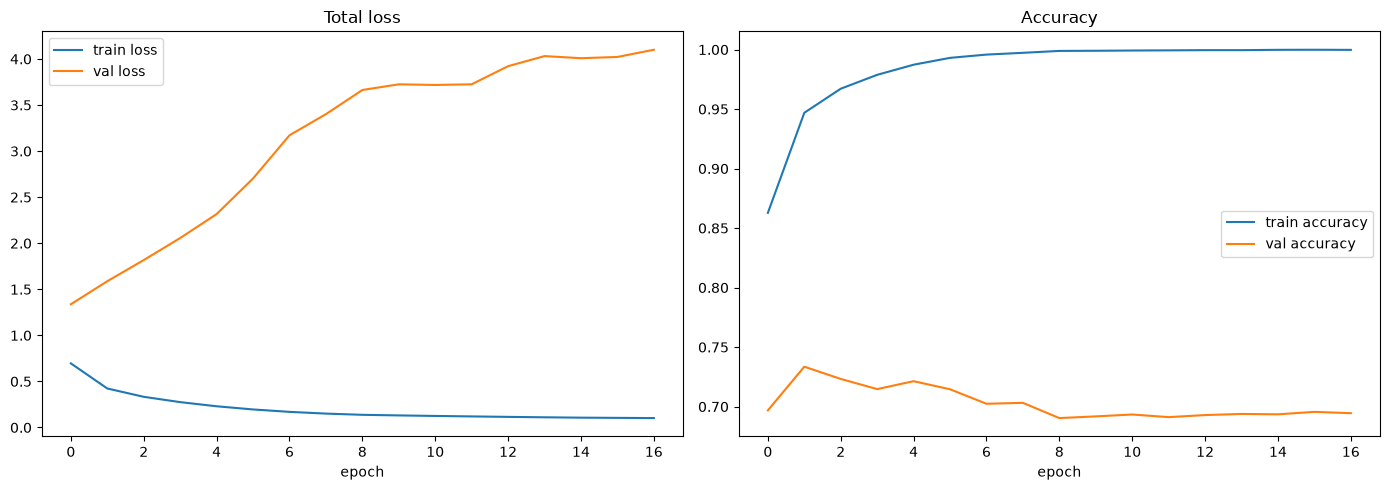

In [18]:
hist = history.history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist["loss"], label="train loss")
axes[0].plot(hist["val_loss"], label="val loss")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(hist["accuracy"], label="train accuracy")
axes[1].plot(hist["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/proposed_model/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

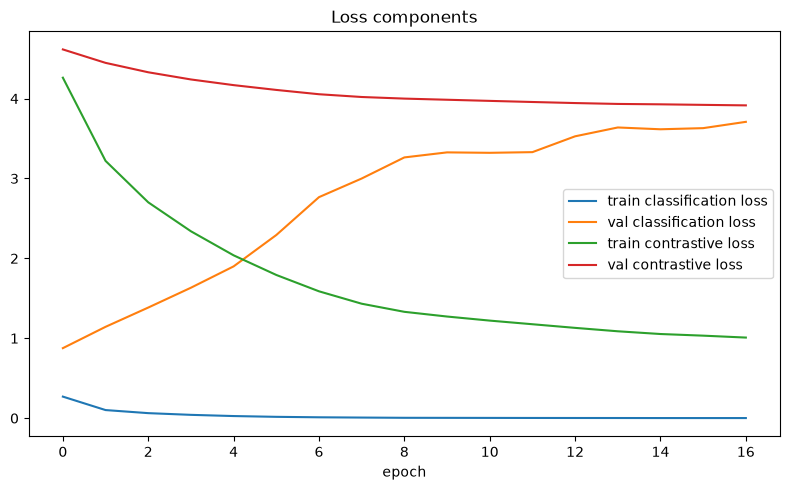

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist["classification_loss"], label="train classification loss")
ax.plot(hist["val_classification_loss"], label="val classification loss")
ax.plot(hist["contrastive_loss"], label="train contrastive loss")
ax.plot(hist["val_contrastive_loss"], label="val contrastive loss")
ax.set_title("Loss components")
ax.set_xlabel("epoch")
ax.legend()
plt.tight_layout()
plt.savefig("figures/proposed_model/training_curves_2.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Testing

In [20]:
# reload the best checkpoint saved during training
best_model = keras.models.load_model("mstc_ids_best.keras", compile=False)

y_pred_proba = best_model((Xc_test, Xp_test, Xt_test, Xf_test), training=False).numpy()
y_pred = np.argmax(y_pred_proba, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.7962


## 17. Classification Report

In [21]:
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall   : {recall:.4f}")
print(f"Weighted F1       : {f1:.4f}")

              precision    recall  f1-score   support

      Benign       0.86      0.98      0.92      1411
         DoS       0.64      0.93      0.76      1748
      Replay       0.82      0.36      0.50      1798
    EvilTwin       1.00      1.00      1.00       850
         FDI       1.00      1.00      1.00       518

    accuracy                           0.80      6325
   macro avg       0.86      0.86      0.84      6325
weighted avg       0.82      0.80      0.77      6325

Weighted Precision: 0.8187
Weighted Recall   : 0.7962
Weighted F1       : 0.7734


## 18. Confusion Matrix

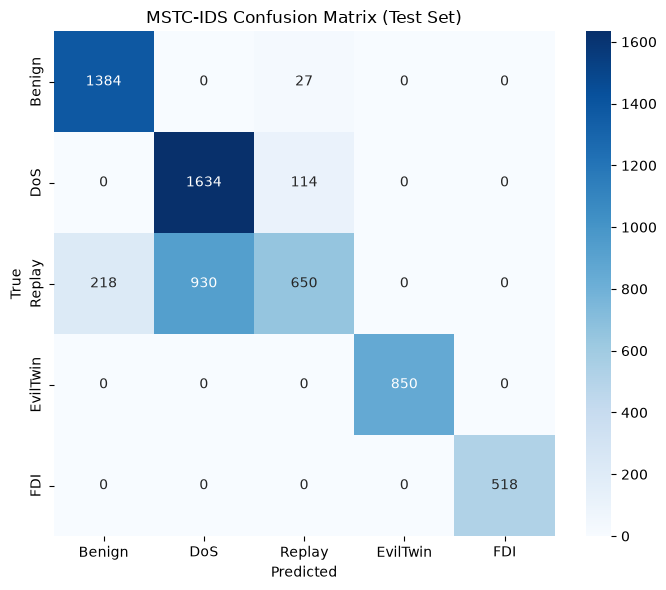

In [22]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("MSTC-IDS Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("figures/proposed_model/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 19. ROC-AUC Analysis

Macro-average AUC   : 0.9176
Weighted-average AUC: 0.8854


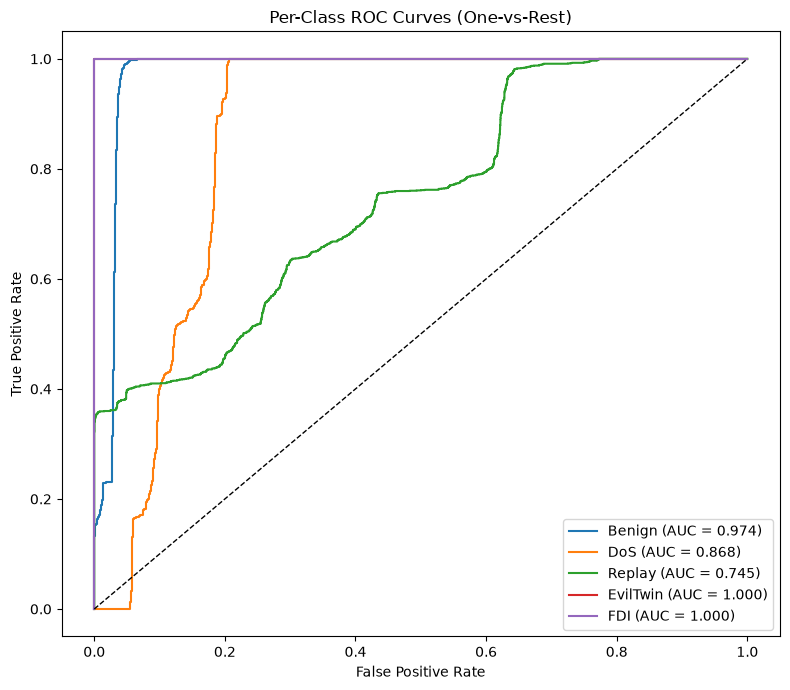

In [23]:
y_test_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="macro")
weighted_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="weighted")
print(f"Macro-average AUC   : {macro_auc:.4f}")
print(f"Weighted-average AUC: {weighted_auc:.4f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i in range(NUM_CLASSES):
    ax.plot(fpr[i], tpr[i], label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Per-Class ROC Curves (One-vs-Rest)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/proposed_model/roc_auc_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 20. MC-Dropout Uncertainty Estimation

Runs `n_samples` stochastic forward passes with dropout kept active (`training=True`)
to obtain a predictive mean and per-sample uncertainty (std across samples), then
performs a focused analysis on the **Replay** class, which is expected to be the
hardest to separate from Benign traffic at the packet level.

In [24]:
mean_pred, uncertainty, all_pred = mc_dropout_predict(
    best_model, (Xc_test, Xp_test, Xt_test, Xf_test), n_samples=50
)

confidence = np.max(mean_pred, axis=1)
print("Average confidence  :", confidence.mean().round(4))
print("Average uncertainty :", uncertainty.mean().round(4))

mc_results = evaluate_predictions(y_test, mean_pred, CLASS_NAMES)

Average confidence  : 0.8845
Average uncertainty : 0.0409

MSTC-IDS Test Results
Accuracy : 0.7911
Precision: 0.8085
Recall   : 0.7911
F1 Score : 0.7695
AUC      : 0.9149

Classification Report
              precision    recall  f1-score   support

      Benign       0.86      0.96      0.91      1411
         DoS       0.64      0.93      0.76      1748
      Replay       0.79      0.36      0.50      1798
    EvilTwin       1.00      1.00      1.00       850
         FDI       1.00      1.00      1.00       518

    accuracy                           0.79      6325
   macro avg       0.86      0.85      0.83      6325
weighted avg       0.81      0.79      0.77      6325


Confusion Matrix
[[1355    0   56    0    0]
 [   0 1627  121    0    0]
 [ 215  929  654    0    0]
 [   0    0    0  850    0]
 [   0    0    0    0  518]]


In [25]:
replay_results = replay_analysis(
    y_test, mean_pred, uncertainty, replay_label=LABEL_MAP["replay"]
)


Replay Attack Analysis
Replay Recall: 0.3637
Average Confidence: 0.9040
Average Uncertainty: 0.0362


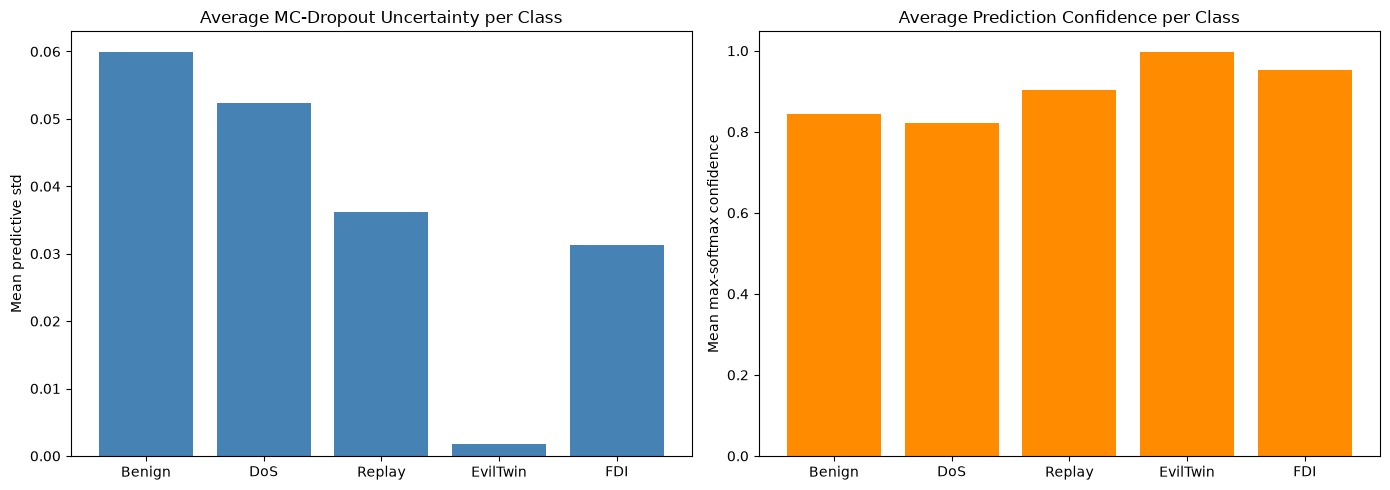

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

per_class_unc = [uncertainty[y_test == i].mean(axis=1).mean() for i in range(NUM_CLASSES)]
axes[0].bar(CLASS_NAMES, per_class_unc, color="steelblue")
axes[0].set_title("Average MC-Dropout Uncertainty per Class")
axes[0].set_ylabel("Mean predictive std")

per_class_conf = [confidence[y_test == i].mean() for i in range(NUM_CLASSES)]
axes[1].bar(CLASS_NAMES, per_class_conf, color="darkorange")
axes[1].set_title("Average Prediction Confidence per Class")
axes[1].set_ylabel("Mean max-softmax confidence")

plt.tight_layout()
plt.savefig("figures/proposed_model/mc_dropout_uncertainty_estimation.png", dpi=150, bbox_inches="tight")
plt.show()

## 21. Save Results

Persists the final model, scalers, windowed test arrays (so `evaluate_mstc_ids.py`
can be run standalone later), training history, and a summary metrics file.

In [27]:
os.makedirs("processed_data", exist_ok=True)
os.makedirs("results", exist_ok=True)

# final model (best checkpoint already saved as mstc_ids_best.keras during training)
best_model.save("mstc_ids_final.keras")

# windowed arrays for standalone evaluate_mstc_ids.py reuse
np.save("Xc_test.npy", Xc_test)
np.save("Xp_test.npy", Xp_test)
np.save("Xt_test.npy", Xt_test)
np.save("Xf_test.npy", Xf_test)
np.save("y_test.npy", y_test)

# training history
with open("results/training_history.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in hist.items()}, f, indent=2)

# summary metrics
summary = {
    "test_accuracy": float(test_accuracy),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1": float(f1),
    "macro_auc": float(macro_auc),
    "weighted_auc": float(weighted_auc),
    "mc_dropout": {
        "avg_confidence": float(confidence.mean()),
        "avg_uncertainty": float(uncertainty.mean()),
    },
    "replay_analysis": {k: float(v) for k, v in replay_results.items()},
    "class_names": CLASS_NAMES,
    "n_cyber_features": int(n_cyber),
    "n_physical_features": int(n_phys),
    "window_size": WINDOW_SIZE,
}
with open("results/summary_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print("  mstc_ids_final.keras / mstc_ids_best.keras")
print("  cyber_scaler.pkl / physical_scaler.pkl")
print("  Xc_test.npy, Xp_test.npy, Xt_test.npy, Xf_test.npy, y_test.npy")
print("  results/training_history.json")
print("  results/summary_metrics.json")

Saved:
  mstc_ids_final.keras / mstc_ids_best.keras
  cyber_scaler.pkl / physical_scaler.pkl
  Xc_test.npy, Xp_test.npy, Xt_test.npy, Xf_test.npy, y_test.npy
  results/training_history.json
  results/summary_metrics.json
